In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import wordcloud
import seaborn as sns
from langdetect import detect, DetectorFactory
import spacy

ConfigError: unable to infer type for attribute "REGEX"

In [2]:
#Importing dataset and take a look at the first 5 rows
reddit_employ = pd.read_csv("D:/reddit_employment_trends/data/raw/reddit_employment_master.csv")
reddit_employ.head()

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with ...,https://preview.redd.it/1ry0labugyig1.png?widt...,Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2e...
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -...,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e...
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is th...","Hello,\n\nfor planning a first trip to North V...",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2d...
3,VietNam,bug bite help,"Hi, I’ve had this bug bite for over a week and...",lilpress13,6,32,2026-02-11 18:11:06,https://i.redd.it/k0jayy3l6yig1.jpeg
4,VietNam,My friend just lost her mom,"Hi, \n\nMy good friend and coworker lost her m...",MeowMeow_77,6,4,2026-02-11 16:00:16,https://www.reddit.com/r/VietNam/comments/1r29...


In [3]:
# Review number of entries and columns
reddit_employ.shape

(2800, 8)

In [4]:
reddit_employ.describe()

,score,num_comments
count,2800.000000,2800.000000
mean,106.477500,27.591786
std,550.877377,58.805972
min,0.000000,0.000000
25%,1.000000,3.000000
50%,8.000000,9.000000
75%,48.000000,26.000000
max,18642.000000,787.000000


In [5]:
# Created a copy of the reddit_employ dataset
pd.set_option("display.max_colwidth", None) # Take a peak at the whole text to see the usual pattern of a thread
reddit_df = reddit_employ.copy()
reddit_df.head(3)

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with clean broth,"https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC.",Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2ecng/how_to_cook_authentic_hanoi_style_pho_ga_with/
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one?","Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver.",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2dj6j/moc_chau_ta_xua_ha_giang_sapa_which_is_the_least/


Phân bổ theo Subreddit: Vẽ biểu đồ cột xem lượng bài viết đến từ Subreddit nào nhiều nhất (r/Vietnam, r/OverseasVietnamese, hay r/Immigration...).

Since we intentionally scrape 200 topics from each subreddits, we can expect a pretty balanced distribution among the subreddits

C:\Users\Dung.000\AppData\Local\Temp\ipykernel_34232\4294811868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = subreddit_counts,


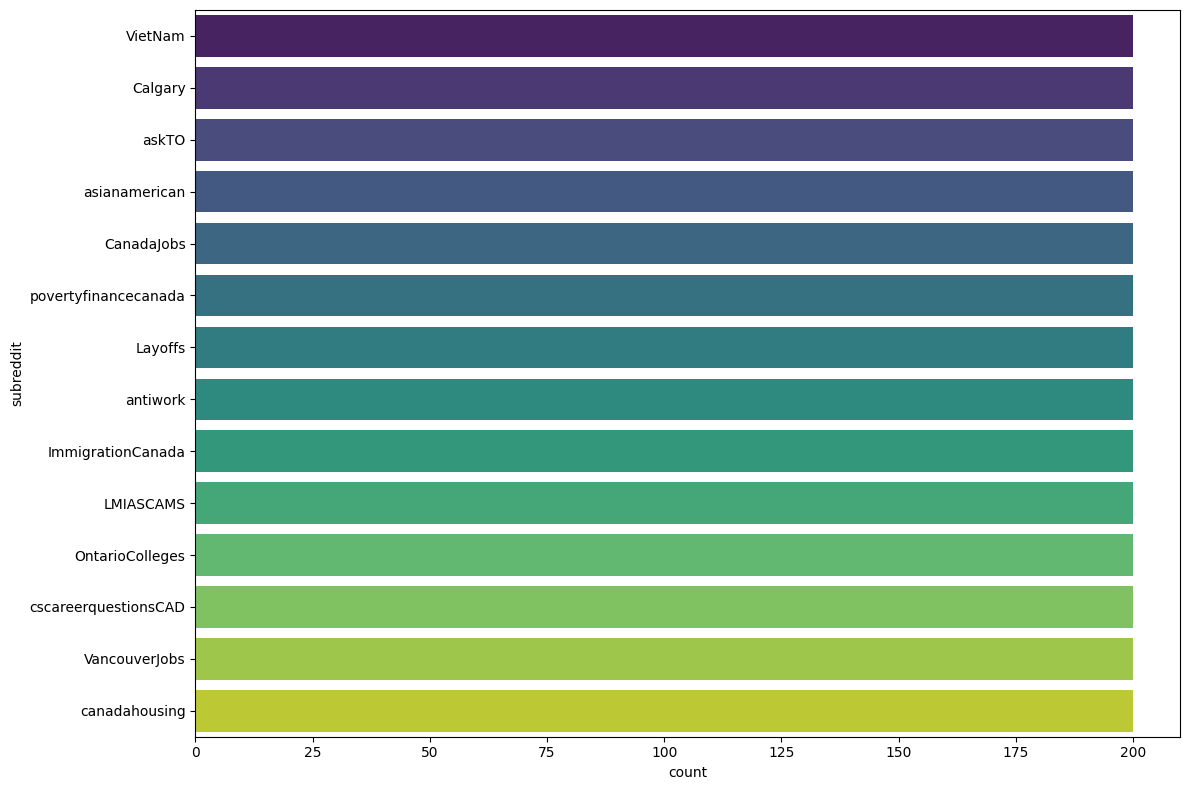

In [6]:
# Count how many texts are there in each subreddits
subreddit_counts = reddit_df['subreddit'].value_counts().reset_index()
subreddit_counts.columns = ['subreddit', 'count']

plt.figure(figsize =(12, 8))
sns.barplot(data = subreddit_counts,
            x = 'count', y = 'subreddit', 
            palette = 'viridis')

plt.tight_layout()
plt.savefig('subreddit_counts.png')
plt.show()

In [7]:
# Checking for any null values
reddit_df.isnull().sum()

subreddit         0
title             0
selftext        449
author            0
score             0
num_comments      0
created_utc       0
url               0
dtype: int64

There're approximately 449 text that are null in the `selftext` column, let's fill null values with blank spaces first for NLP purpose later.

In [8]:
# Fill `selftext` column with "" first
reddit_df['selftext'] = reddit_df['selftext'].fillna("")
print(reddit_df.isnull().sum())

subreddit       0
title           0
selftext        0
author          0
score           0
num_comments    0
created_utc     0
url             0
dtype: int64


In [12]:
# Combine `title` & `selftext` columns together since titles contain the main ideas, selftext contains details => more convenients when doing EDA later
reddit_df['full_text'] = reddit_df['title'] + " " + reddit_df["selftext"]
# check the full_text column
reddit_df['full_text'].head()

0    How to cook authentic Hanoi style Pho Ga with clean broth https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n  \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n  \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n  \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n  \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC. 
1                                                                                                                                                                                                                              

The subreddits are mostly in English, the rest are other languages (including Vietnamese). Since our concerns in this project is about Vietnamese and English, we'll sort out other languages (e.g. French, Japanese, etc.)

## 2. Language detection
Since `underthesea` is for Vietnamese, we'll need `Spacy` to work with English

- Devide the datasets into two: `english_df` and `vietnamese_df`, for those text that contains both english and vietnamese (Vinglish), prioritize the one that outnumber

In [14]:
from langdetect import detect

def get_language(text):
    try:
        return detect(text)
    except:
        return "uknown"
    
# Apply the function to create another columns 
reddit_df['language'] = reddit_df['full_text'].apply(get_language)

# Create 2 different datasets with vietnames and english
reddit_vn = reddit_df[reddit_df['language'] == "vi"].copy()
reddit_en = reddit_df[reddit_df['language'] == "en"].copy()

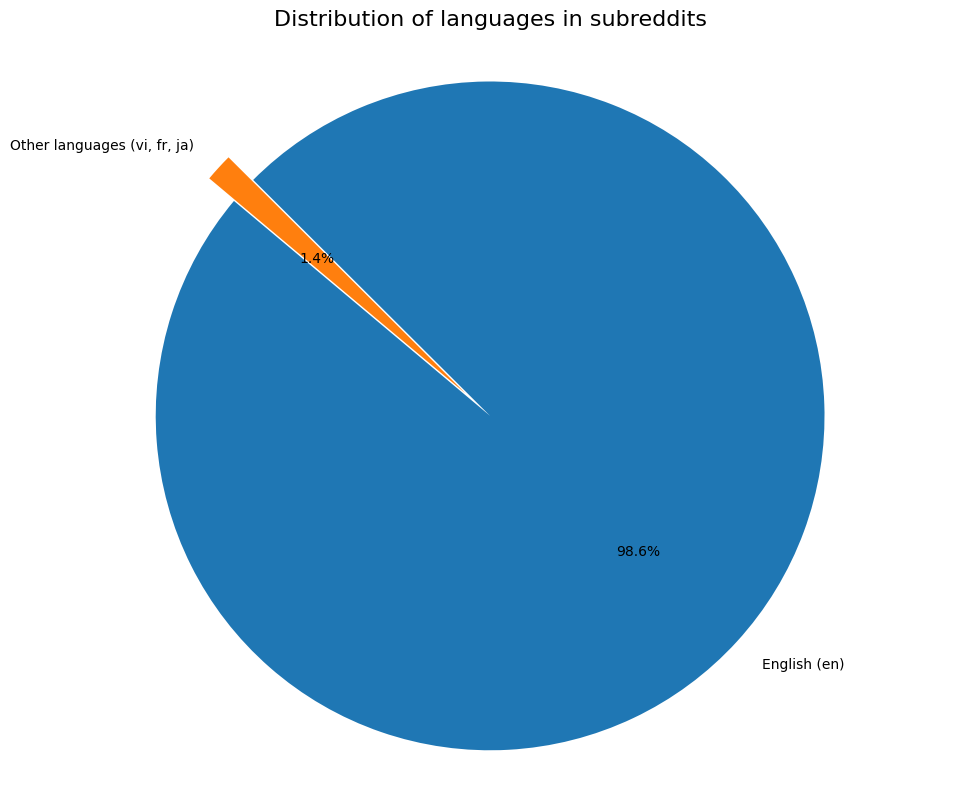


Detailed Distribution table:
language
en        2762
vi           7
de           7
fr           7
ca           3
nl           3
tl           2
uknown       1
sk           1
no           1
cy           1
so           1
sw           1
it           1
da           1
ro           1
Name: count, dtype: int64


In [15]:
# Make sure the results are reproducible
DetectorFactory.seed = 0

lang_counts = reddit_df['language'].value_counts()
en_counts = lang_counts.get('en', 0) # Separate subreddits with english apart from the others
other_counts = lang_counts.sum() - en_counts
# Create a new series to draw chart
lang_plot_data = pd.Series({
    "English (en)": en_counts,
    "Other languages (vi, fr, ja)": other_counts
})

#Draw a pie chart
plt.figure(figsize = (10, 8))
# colors = ['']
plt.pie(
    lang_plot_data, 
    labels=lang_plot_data.index,
    autopct= "%1.1f%%", # show percentage
    startangle=140,
    explode=(0, 0.1),  # Create small spaces between slices for easy visibility
)
plt.title("Distribution of languages in subreddits", fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig("language_distribution_chart.png")
plt.show()

print("\nDetailed Distribution table:")
print(lang_counts)

In [16]:
print(f"Subreddits contains Vietnamese has {reddit_vn.shape[0]} rows and {reddit_vn.shape[1]} columns")
print(reddit_vn['full_text']) # Take a peek at these subreddits

Subreddits contains Vietnamese has 7 rows and 10 columns
8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               PUERTO RICO LÃNH THỔ MỸ - DI SẢN KHIẾN THẾ GIỚI NGÃ MŨ VÀ ĐẤU ĐÁ MG Puerto Rico không nổi lên nhờ may mắn. Nó được tôi luyện qua 500 năm va chạm giữa Tây Ban Nha, Mỹ và bản sắ

We can see that with these text, even when there are Vietnamese, some of them are still written mainly in English, we can see that even with immigrants, in this case Vietnamese immigrants, **we still prioritize using English to navigate through the procecss of settling down or receiving helps from international friends**.
=> Therfore, we still use `underthesea` to extract important features from these 7 subreddits but our main focus will be on the rest of the dataset, which is mostly written in English

In [52]:
reddit_df.head()

,subreddit,title,selftext,author,score,num_comments,created_utc,url
0,VietNam,How to cook authentic Hanoi style Pho Ga with clean broth,"https://preview.redd.it/1ry0labugyig1.png?width=650&amp;format=png&amp;auto=webp&amp;s=9fae680bd17ffd802cad36e8fadcce09aa6a7101\n\n\n\n \nI wanna cook pho ga that looks like this that has clean broth, not dark brown or cloudy broth.\n\n \nI tried today using star anise, fennel seeds, cinnamon sticks, cloves + Japanese MSG but no fish sauce and it turned out to be thick brown that tastes like HCM style pho to me.\n\n \nI boiled chicken meat (Not the whole chicken but pieces including chicken thighs, legs and breasts) for like 40-50mins as well.\n\n \nCan somebody tell me how I can cook like above photo? \n\nI followed one Hanoi Pho Ga recipe recipe online and it tastes like typical Pho I had in HCMC.",Important_Back_7132,1,0,2026-02-11 19:12:42,https://www.reddit.com/r/VietNam/comments/1r2ecng/how_to_cook_authentic_hanoi_style_pho_ga_with/
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
2,VietNam,"Moc Chau, Ta Xua, Ha Giang, Sapa - Which is the least favourite one?","Hello,\n\nfor planning a first trip to North Vietnam as a tourist I am in Hanoi for around two weeks. My plan would be as following:\n\n01.05 - 03.05 Moc Chau\n\n03.05 - 05.05 Ta Xua\n\n05.05 - 06.05 Hanoi (seems like there is no direct way from Ta Xua to Ha Giang)\n\n06.05 - 07.05 Ha Giang\n\n08.05 - 11.05 Sapa\n\n \nDoes the amount of spending days make sense? I am a little afraid of the long bus travels between those locations. And if you were to advise against one place, which one would it be? Not sure if I can meet all those places on time. PS.: I am not a motorcycle driver.",Firehead1971,1,3,2026-02-11 18:38:28,https://www.reddit.com/r/VietNam/comments/1r2dj6j/moc_chau_ta_xua_ha_giang_sapa_which_is_the_least/
3,VietNam,bug bite help,"Hi, I’ve had this bug bite for over a week and it keeps getting larger despite topical medicine from the pharmacy. The yellowish ring is one of the medicines they gave me. It is incredibly itchy. It hasn’t gotten better after over three days of the medicine, does anyone know what it could be/is it cause for concern/should I go to a doctor? It’s about the size of a quarter. I am in central Vietnam. I also have a sore throat but am not sure if they are related. I have no other symptoms. Thank you for any help 🙇‍♀️♥️",lilpress13,6,32,2026-02-11 18:11:06,https://i.redd.it/k0jayy3l6yig1.jpeg
4,VietNam,My friend just lost her mom,"Hi, \n\nMy good friend and coworker lost her mom earlier this week. My friend is originally from Vietnam and I would like to show respect and sympathy. My coworkers and I are pulling money together to get a gift for her. I was wondering if there is anything special or traditional that we can do for her. We are in the states and typically have a card that everyone signs and flowers. Is there anything else I can do for her? \n\nThank you in advance.",MeowMeow_77,6,4,2026-02-11 16:00:16,https://www.reddit.com/r/VietNam/comments/1r29gog/my_friend_just_lost_her_mom/


## 3. Data Cleaninga & Pre-processing

1. Overall cleaning: Delete URL, HTML Tags, Emojii, and special keywords
2. Tackle Vietnamese, use `underthesea.text_normalize` and `word_tokenize`
3. Tackle English, use `NLTK` for lowercase, remove stopwords and Lemmatization

In [ ]:
# Iterate through each subreddit and see how much of null values in each topic
subreddits =[
    "VietNam", "Calgary", "askTO", "asianamerican",            
    "CanadaJobs", "povertyfinancecanada", "Layoffs", "antiwork", # General Market
    "ImmigrationCanada", "LMIASCAMS", "OntarioColleges",        # Immigration
    "cscareerquestionsCAD", "VancouverJobs", "canadahousing"  # Niche/Regional
]



Since the null column in `selftext` takes roughly 16% of the total dataset and Reddit users are more likely to express their ideas in the `title`

In [15]:
reddit_df[reddit_df['selftext'].isnull()]

,subreddit,title,selftext,author,score,num_comments,created_utc,url
1,VietNam,Getting Levothyroxine for thyroid in Vietnam -- any problems obtaining it without a prescription?,NaN,FrancoisMauriac,1,0,2026-02-11 19:05:56,https://www.reddit.com/r/VietNam/comments/1r2e6zv/getting_levothyroxine_for_thyroid_in_vietnam_any/
10,VietNam,Bộ chuyển đổi Quốc Ngữ → Quốc Âm Tân Tự (QATT),NaN,PatataYeh,0,0,2026-02-11 12:52:20,https://i.redd.it/afqyz1dpjwig1.jpeg
40,VietNam,Ba Na Hills,NaN,Ill_Fish9888,4,1,2026-02-10 22:49:53,https://v.redd.it/tactrqrefsig1
41,VietNam,Left my heart in the land of the dragon.,NaN,Ill_Fish9888,33,1,2026-02-10 22:48:42,https://www.reddit.com/gallery/1r1mt4e
83,VietNam,Language exchange,NaN,revenge3swEET1929,0,0,2026-02-10 03:23:43,/r/Vietnamese/comments/1r0v8sn/language_exchange/
...,...,...,...,...,...,...,...,...
2788,canadahousing,‘They have not received a raise in 25 years’: Young men are now being out-earned by seniors for the first time ever,NaN,AnarchoLiberator,599,129,2025-12-12 14:27:54,https://thehub.ca/podcast/video/they-have-not-received-a-raise-in-25-years-young-men-are-now-being-out-earned-by-seniors-for-the-first-time-ever/
2789,canadahousing,'Shadow demand': Why Canadian rents could hit a floor sooner than expected,NaN,D_E_A_D_P_O_O_L_,98,91,2025-12-12 11:45:30,https://ca.finance.yahoo.com/news/shadow-demand-why-canadian-rents-could-hit-a-floor-sooner-than-expected-120000385.html
2792,canadahousing,Bank of Canada Holds Policy Rate at 2.25% in Final 2025 Decision,NaN,MightBeneficial3302,39,8,2025-12-10 10:17:19,https://bankofcanadaodds.com/insight/bank-of-canada-holds-policy-rate-at-2-25-in-final-2025-decision/
2793,canadahousing,Canada’s Big Banks are a ‘culprit’ driving housing prices out of control,NaN,rezwenn,1021,229,2025-12-09 22:19:02,https://breachmedia.ca/canadas-big-banks-are-a-culprit-driving-housing-prices-out-of-control/


In [ ]:
# Lowercase for the 'selftext' column
reddit_df['selftext_clean'] = reddit_df['selftext'].str.lower()
# Review the clean column
reddit_df['selftext_clean'].head()

In [ ]:
# Before deleting all of the text inside [], let's check them out first
reddit_df[reddit_df['selftext_clean'].str.contains(r'\[.*\]')]

,subreddit,title,selftext,author,score,num_comments,created_utc,url,selftext_clean
122,VietNam,Early May in Vietnam for 2 nights. Where to?,\n\n[View Poll](https://www.reddit.com/poll/1r...,kimtoshi,0,3,2026-02-09 10:54:49,https://www.reddit.com/r/VietNam/comments/1r07...,\n\n[view poll](https://www.reddit.com/poll/1r...
228,Calgary,The 2026 Olympics that Calgary chose not to bi...,Jeremy Klauzus's Sprawlcast (a long form journ...,senecant,182,148,2026-02-10 22:57:28,https://www.reddit.com/r/Calgary/comments/1r1m...,jeremy klauzus's sprawlcast (a long form journ...
279,Calgary,Recall Myles McDougall - All Day Signing Event...,Come join us for our all day signing event. We...,RecallMyles,47,14,2026-02-08 12:25:17,https://i.redd.it/zwhzfgb52big1.png,come join us for our all day signing event. we...
303,Calgary,"‘I can’t stress that enough, I’m scared’: Calg...",My friends house is being targeted. They are b...,superanx,977,202,2026-02-07 10:28:14,https://www.ctvnews.ca/calgary/article/i-cant-...,my friends house is being targeted. they are b...
382,Calgary,Mayor Farkas: address the e-bike issue before ...,***u/***[JeromyYYC](https://www.reddit.com/us...,morecoffeemore,441,370,2026-02-04 15:11:50,https://www.reddit.com/r/Calgary/comments/1qvz...,***u/***[jeromyyyc](https://www.reddit.com/us...
...,...,...,...,...,...,...,...,...,...
2757,canadahousing,Canada Weighs Opening Its Housing Market to Mo...,*Canada is considering changes to its ban on f...,PsychedTechie,365,211,2025-12-23 10:37:40,https://www.reddit.com/r/canadahousing/comment...,*canada is considering changes to its ban on f...
2773,canadahousing,Vancouver Government to allow 32 Storey Social...,[https://dailyhive.com/vancouver/downtown-east...,FLLCY,29,11,2025-12-17 17:25:49,https://www.reddit.com/r/canadahousing/comment...,[https://dailyhive.com/vancouver/downtown-east...
2780,canadahousing,"Even in this market, Detached homes are consid...","To remind everyone, I started [**Hawss.com**](...",MacaronTasty1371,13,6,2025-12-16 10:47:56,https://i.redd.it/xwx771kk4l7g1.png,"to remind everyone, i started [**hawss.com**](..."
2782,canadahousing,Canada Inflation Looks Stable at 2.2% Until Yo...,[https://bankofcanadaodds.com/insight/canada-i...,MightBeneficial3302,383,156,2025-12-15 10:16:27,https://i.redd.it/ldvzo5izwd7g1.jpeg,[https://bankofcanadaodds.com/insight/canada-i...


There're a total of 288 columns containing `[]`, some of them are for clarifiying/specifying the content that the Reddit users are writing but some of them has a link inside of it. For the purpose of training ML model later, we'll replace those links with `[LINK]` inside

### Charts to include
1. Content and topic analysis:

**Bar chart** (Top N keywords/biagrams): đếm tần suất các cụm 2 từ như "tìm việc", "kinh nghiệm" "lương bổng" xuất hiện

**Topic modelling visualization (LDAvis)**: nhóm các bài viết thành chủ đề tự động => Cho thấy các bong bóng chủ đều tách biệt nhau như thế nào

2. Sentimental Analysis

**Pie chart/Donue chart** (Sentimental Distribution): So sánh xem cộng đồng ở Subreddits nào "bi quan" hay "lạc quan" hơn về thị trường lao động.

**Heatmap** (Sentiment vs. Time of Day/Day of Week): xem thử liệu các bài đăng vào thứ 2 (khi scrape) thường mang tâm trạng gì so với các ngày khác.

3. Trend and Engagement Analysis

**Time Series Line chart (post Volume/Time)**: Theo dõi số lượng bài đăng theo tuần/tháng. Nếu có 1 đợt sóng bài đăng đột ngột, có thể do 1 chính sách mới vừa ra đời.

**Scatter Plot** (Upvotes vs Number of Comments): xác định những chủ đề gây tranh cãi (debatable) hoặc được "quan tâm" nhất. Những bài ít vote nhưng nhiều cmmt thường là chủ đề gây tranh cãi.

**Stacked Bar Chart (Top skills mentioned by Industry)**: nếu phân loại được ngành nghề (IT, Marketing, ...) biểu đồ này sẽ chỉ ra SKILLS nào đang chiếm sóng trong mỗi 

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

# Put it into Spacy pipeline
def get_keywords(text):
    doc = nlp(text[:10000])

    # Get PROPN and NOUN
    # Remove stop words and punctuations
    keywords = [
        token.lemma_.lower() for token in doc 
        if (token.pos_ in ['PROPN', 'NOUN'])
        and not token.is_stop
        and not token.is_punct
    ]
    return keywords

# Apply for the whole dataset
all_keywords =[]
for text in reddit_en['full_text']:
    all_keywords.extend(get_keywords(text))

# Get the top 20 keywords
top_keywords = Counter(all_keywords).most_common(20)

# Cretae dataframe to plot the chart
reddit_top_20 = pd.DataFrame(all_keywords, columns = ['Keyword', 'Count'])
print("\nTop 20 keywords:")
print(reddit_top_20)

ConfigError: unable to infer type for attribute "REGEX"

In [ ]:
# Plot top 20 keywords and their occurences
plt.figure(figsize=(12, 8))
sns.barplot(data = reddit_top_20, x = "Count", y = "Keyword", palette="magma")
plt.title("Top 20 keywords/Skills are debated the most in Reddit")
plt.xlabel("Occurences")
plt.ylabel("Keywords")
plt.show()

## 4. Text Mining EDA
1. Finding Top N-Grams
- English: might be "work permit", "PR", "PR process", "job market"
- Vietnamses: "xin việc", "định cư", "bằng cấp"
2. Word Cloud: draw 2 separate clouds for 2 languages to find the difference in concerns

## 5. Enagagement Analysis
- **Correlation**: Are the text about "immigrations" receive more upvotes than the ones with "food"/"recreation"?
- **Time**: Every time we scrape the dataset on Monday, check lượng thảo luận có tăng đột biến sau holidays hay chính sách mới không?

## 6. Initial Sentiment EDA
- Use simple libraries like `TextBlob` (for English) to see general attitude (negative or positive) before diving deeper into more complex models